In [1]:
from pathlib import Path

import pandas as pd

from dd_kable_analysis.config_loader import load_config


In [2]:
import re

from dd_kable_analysis.data_io import load_tsv_data, resolve_file

cfg = load_config()

subject_list_path = Path(cfg.subject_lists) / 'mvpa_subject_list.txt'
subject_ids = [
    line.strip() for line in subject_list_path.read_text().splitlines() if line.strip()
]

run_re = re.compile(r'_run-([^_]+)_')

all_runs = []
missing_bids = []
missing_sv = []

for sub_id in subject_ids:
    sv_dir = Path(cfg.output_root) / 'subjective_value_estimates' / f'sub-{sub_id}'

    # Get all SV paths for this subject
    sv_paths = sorted(
        sv_dir.glob(
            f'ses-*/func/sub-{sub_id}_ses-*_task-dd_run-*_desc-subjectivevalue_events.tsv'
        )
    )

    sv_by_run = {}
    for p in sv_paths:
        m = run_re.search(p.name)
        if m:
            sv_by_run[m.group(1)] = p

    if not sv_paths:
        missing_sv.append(sub_id)

    # Try each run using resolve_file for BIDS data
    # We need to figure out which runs exist for this subject
    # Try runs 1-5 and catch failures
    for run_num in range(1, 6):
        run_id = str(run_num)

        try:
            bids_path = resolve_file(cfg, sub_id, 'scan1', run_id, 'behav')
        except ValueError:
            # This run doesn't exist for this subject, skip it
            continue

        bids_df = load_tsv_data(bids_path).copy()
        bids_df['sub_id'] = sub_id
        bids_df['run'] = run_id
        bids_df['source_bids_tsv'] = str(bids_path)
        bids_df['_onset_key'] = pd.to_numeric(bids_df['onset'], errors='coerce').round(
            6
        )

        sv_path = sv_by_run.get(run_id)

        if sv_path is not None:
            sv_df = load_tsv_data(sv_path).copy()
            sv_df['_onset_key'] = pd.to_numeric(sv_df['onset'], errors='coerce').round(
                6
            )

            # Keep subjective-value columns if present
            sv_cols = ['_onset_key', 'SV_LL', 'SV_chosen', 'SV_unchosen', 'SV_SS', 'DV']
            sv_cols = [c for c in sv_cols if c in sv_df.columns]
            sv_df = sv_df[sv_cols].drop_duplicates(subset=['_onset_key'], keep='first')

            merged = bids_df.merge(
                sv_df, on='_onset_key', how='left', validate='many_to_one'
            )
            merged['source_sv_tsv'] = str(sv_path)
        else:
            merged = bids_df.copy()
            merged['source_sv_tsv'] = pd.NA

        merged = merged.drop(columns=['_onset_key'])
        all_runs.append(merged)

if all_runs:
    mvpa_merged_df = pd.concat(all_runs, ignore_index=True)
else:
    print('Warning: No data loaded!')
    mvpa_merged_df = pd.DataFrame()

# Backward-compatible alias for quick inspection in later cells
mvpa_behav_df = mvpa_merged_df

print(f'Subjects in MVPA list: {len(subject_ids)}')
print(f'Subjects missing subjective-value TSVs: {len(missing_sv)}')
print(f'Merged rows: {len(mvpa_merged_df)}')
print(f'Columns: {list(mvpa_merged_df.columns)}')

mvpa_merged_df.head()


Subjects in MVPA list: 123
Subjects missing subjective-value TSVs: 0
Merged rows: 14730
Columns: ['onset', 'duration', 'amount', 'Delay', 'choseAccept', 'RT', 'choseRight', 'sub_id', 'run', 'source_bids_tsv', 'source_sv_tsv']


/tmp/ipykernel_28649/2852585028.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mvpa_merged_df = pd.concat(all_runs, ignore_index=True)


,onset,duration,amount,Delay,choseAccept,RT,choseRight,sub_id,run,source_bids_tsv,source_sv_tsv
0,15.822,4,66,58,1.0,1.993,1.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
1,24.855,4,39,95,0.0,1.024,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
2,32.888,4,69,172,0.0,1.071,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
3,42.937,4,23,42,0.0,1.101,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
4,56.987,4,77,142,1.0,1.739,1.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN


In [5]:
print(mvpa_merged_df['Delay'].min())
print(mvpa_merged_df['Delay'].max())

print(mvpa_merged_df['amount'].min())
print(mvpa_merged_df['amount'].max())

19
180
22
85


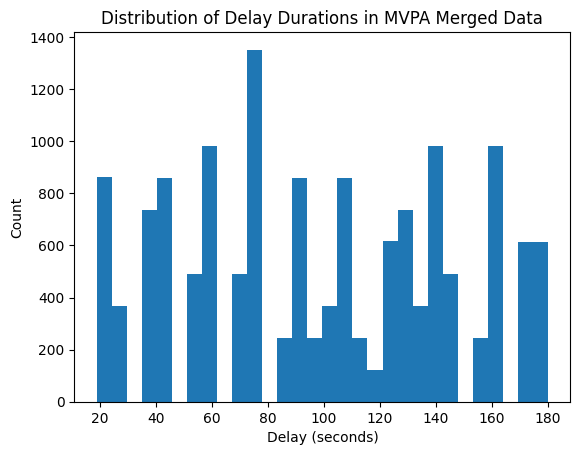

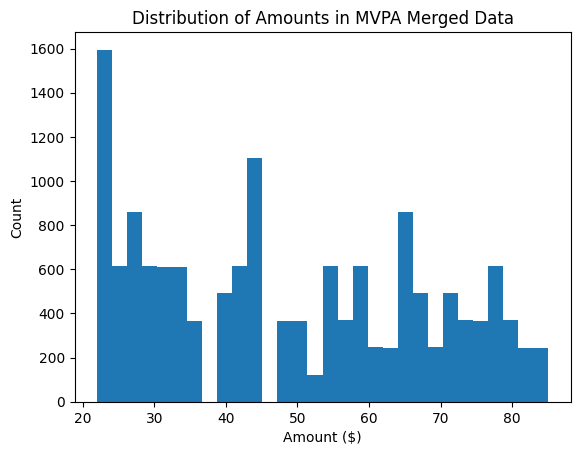

In [3]:
import matplotlib.pyplot as plt

plt.hist(mvpa_merged_df['Delay'].dropna(), bins=30)
plt.xlabel('Delay (seconds)')
plt.ylabel('Count')
plt.title('Distribution of Delay Durations in MVPA Merged Data')
plt.show()

plt.hist(mvpa_merged_df['amount'].dropna(), bins=30)
plt.xlabel('Amount ($)')
plt.ylabel('Count')
plt.title('Distribution of Amounts in MVPA Merged Data')
plt.show()

In [4]:
mvpa_merged_df['amount'].min()

22

/tmp/ipykernel_12730/2069903088.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvpa_merged_df.groupby(['sub_id', 'delay_bin', 'amount_bin'])


Bin counts shape: (3075, 4)

First few rows:
    sub_id delay_bin amount_bin  count
0  dmp0011        Q1         Q1      4
1  dmp0011        Q1         Q2      5
2  dmp0011        Q1         Q3      6
3  dmp0011        Q1         Q4      5
4  dmp0011        Q1         Q5      5
5  dmp0011        Q2         Q1      5
6  dmp0011        Q2         Q2      7
7  dmp0011        Q2         Q3      2
8  dmp0011        Q2         Q4      6
9  dmp0011        Q2         Q5      4


/tmp/ipykernel_12730/2069903088.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_counts = bin_counts.pivot_table(
/tmp/ipykernel_12730/2069903088.py:33: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std_counts = bin_counts.pivot_table(


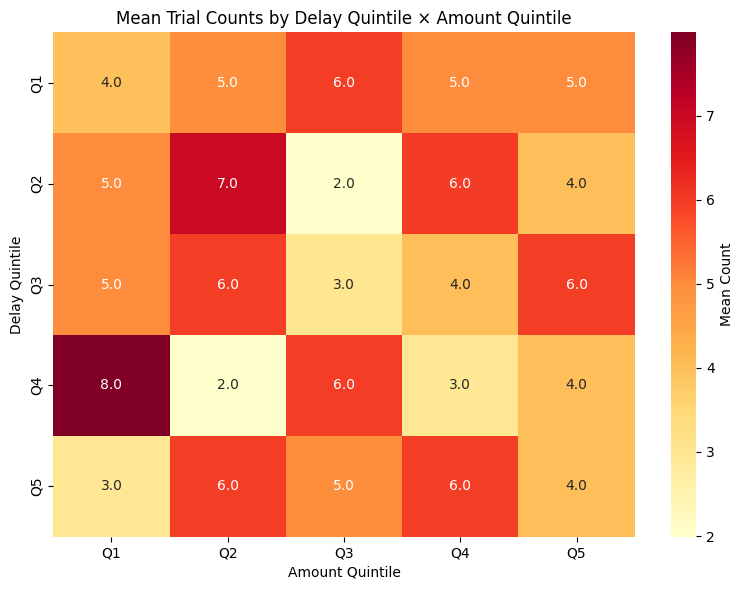

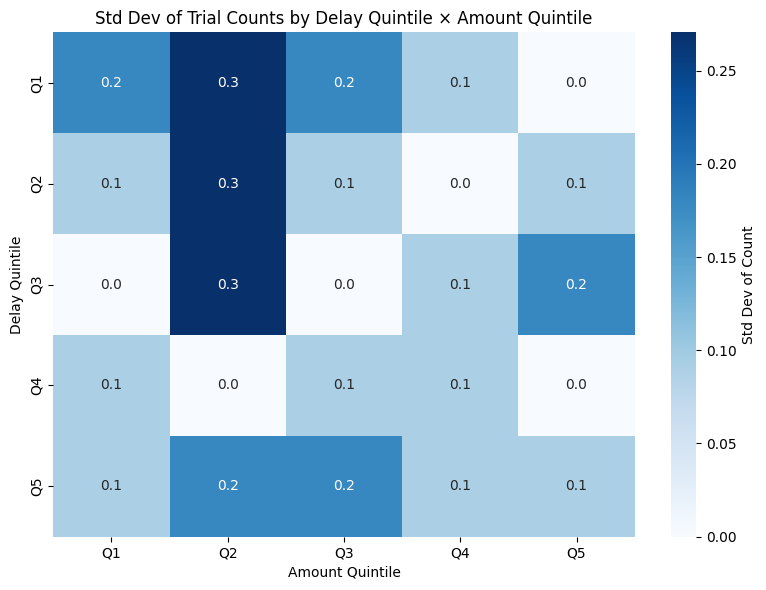

In [5]:
import seaborn as sns

# Create quintile bins for delay and amount
mvpa_merged_df['delay_bin'] = pd.qcut(
    mvpa_merged_df['Delay'],
    q=5,
    labels=[f'Q{i + 1}' for i in range(5)],
    duplicates='drop',
)

mvpa_merged_df['amount_bin'] = pd.qcut(
    mvpa_merged_df['amount'],
    q=5,
    labels=[f'Q{i + 1}' for i in range(5)],
    duplicates='drop',
)

# Get counts for each subject in each bin combination
bin_counts = (
    mvpa_merged_df.groupby(['sub_id', 'delay_bin', 'amount_bin'])
    .size()
    .reset_index(name='count')
)

print(f'Bin counts shape: {bin_counts.shape}')
print('\nFirst few rows:')
print(bin_counts.head(10))

# Create pivot tables for matrix plots
mean_counts = bin_counts.pivot_table(
    index='delay_bin', columns='amount_bin', values='count', aggfunc='mean'
)
std_counts = bin_counts.pivot_table(
    index='delay_bin', columns='amount_bin', values='count', aggfunc='std'
)

# Plot mean counts
plt.figure(figsize=(8, 6))
sns.heatmap(
    mean_counts, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Mean Count'}
)
plt.title('Mean Trial Counts by Delay Quintile × Amount Quintile')
plt.xlabel('Amount Quintile')
plt.ylabel('Delay Quintile')
plt.tight_layout()
plt.show()

# Plot std of counts
plt.figure(figsize=(8, 6))
sns.heatmap(
    std_counts,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Std Dev of Count'},
)
plt.title('Std Dev of Trial Counts by Delay Quintile × Amount Quintile')
plt.xlabel('Amount Quintile')
plt.ylabel('Delay Quintile')
plt.tight_layout()
plt.show()


In [6]:
mean_counts

amount_bin,Q1,Q2,Q3,Q4,Q5
delay_bin,,,,,
Q1,3.98374,4.97561,5.98374,4.99187,5.00000
Q2,4.99187,6.97561,1.99187,6.00000,3.99187
Q3,5.00000,5.97561,3.00000,3.99187,5.98374
Q4,7.99187,2.00000,5.99187,2.99187,4.00000
Q5,2.99187,5.98374,4.98374,5.99187,3.99187


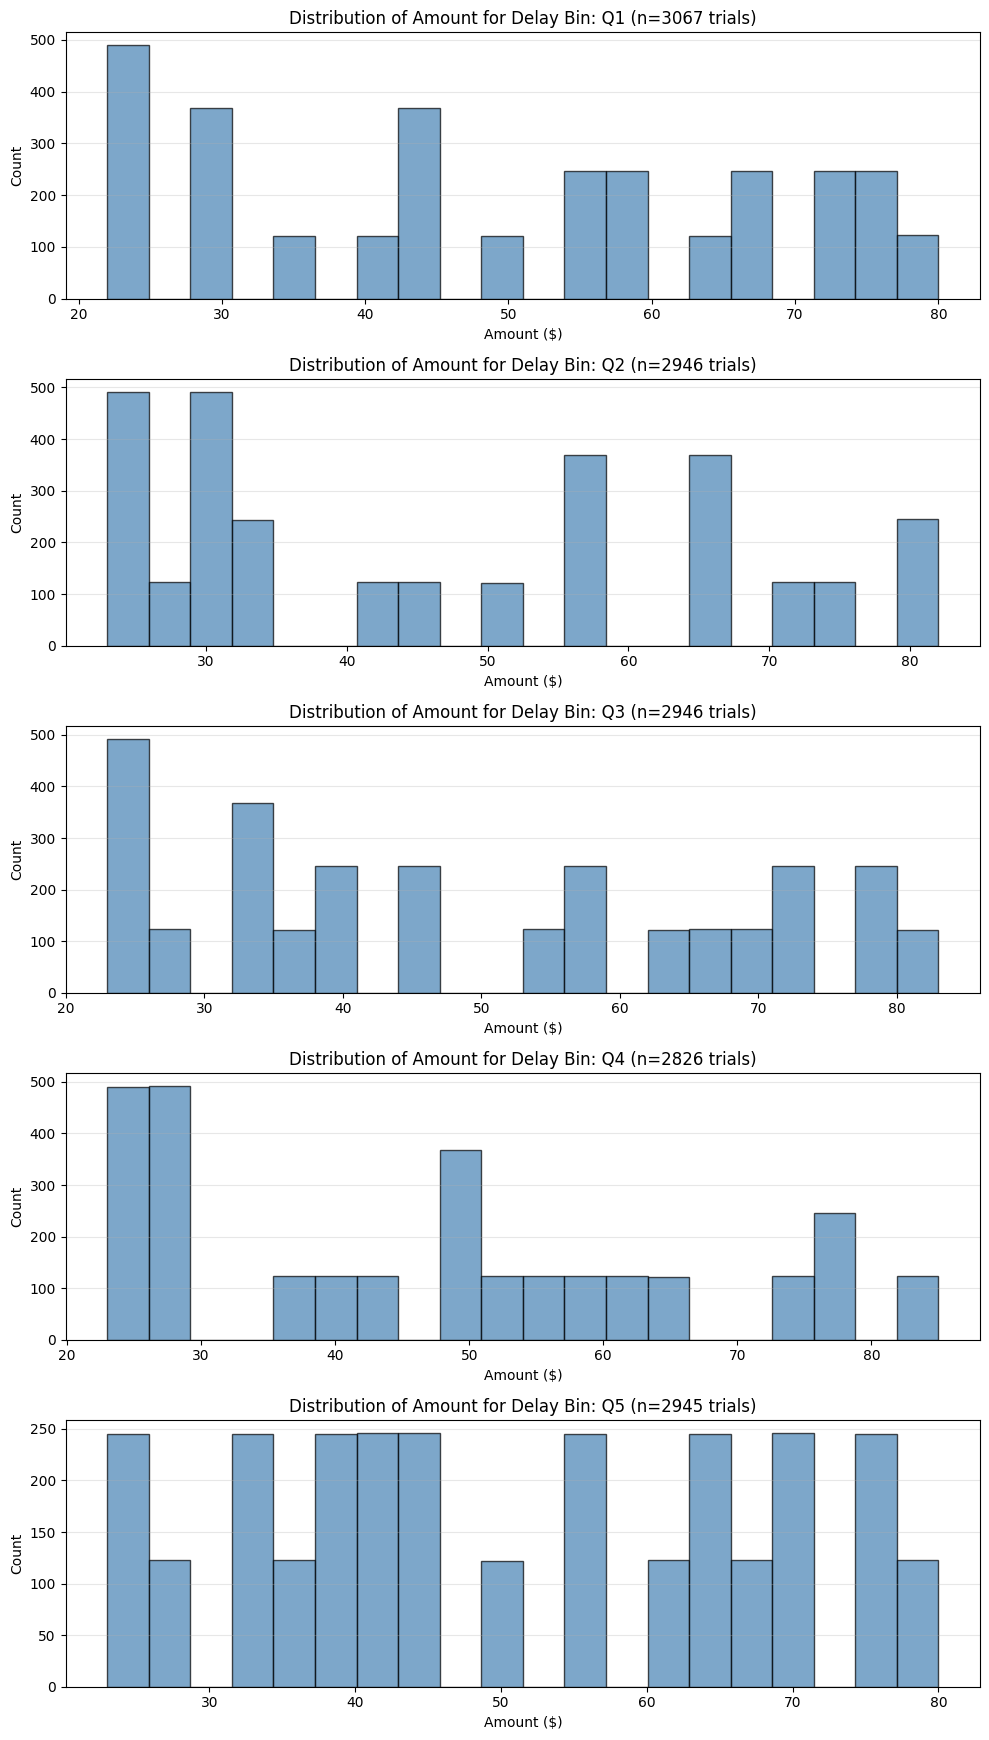

In [7]:
# Plot histogram of amount for each delay bin level
delay_bins_unique = sorted(mvpa_merged_df['delay_bin'].dropna().unique())
n_delay_bins = len(delay_bins_unique)

# Create subplots
fig, axes = plt.subplots(n_delay_bins, 1, figsize=(10, 3.5 * n_delay_bins))
if n_delay_bins == 1:
    axes = [axes]

for idx, delay_bin in enumerate(delay_bins_unique):
    data_in_bin = mvpa_merged_df[mvpa_merged_df['delay_bin'] == delay_bin][
        'amount'
    ].dropna()

    axes[idx].hist(
        data_in_bin, bins=20, edgecolor='black', alpha=0.7, color='steelblue'
    )
    axes[idx].set_xlabel('Amount ($)')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(
        f'Distribution of Amount for Delay Bin: {delay_bin} (n={len(data_in_bin)} trials)'
    )
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


bin_counts_5x3 shape: (1845, 4)
     sub_id delay_5lvl amount_3lvl  count
0   dmp0011         D1          A1      8
1   dmp0011         D1          A2      9
2   dmp0011         D1          A3      8
3   dmp0011         D2          A1     11
4   dmp0011         D2          A2      6
5   dmp0011         D2          A3      7
6   dmp0011         D3          A1      8
7   dmp0011         D3          A2      8
8   dmp0011         D3          A3      8
9   dmp0011         D4          A1      8
10  dmp0011         D4          A2      8
11  dmp0011         D4          A3      7


/tmp/ipykernel_11277/4203521523.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvpa_merged_df.groupby(['sub_id', 'delay_5lvl', 'amount_3lvl'])
/tmp/ipykernel_11277/4203521523.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_counts_5x3 = bin_counts_5x3.pivot_table(
/tmp/ipykernel_11277/4203521523.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std_counts_5x3 = bin_counts_5x3.pivot_table(


amount_3lvl,A1,A2,A3
delay_5lvl,,,
D1,7.96748,8.97561,7.99187
D2,10.96748,5.99187,6.99187
D3,7.98374,7.99187,7.97561
D4,7.99187,7.99187,6.99187
D5,5.98374,8.97561,8.98374


amount_3lvl,A1,A2,A3
delay_5lvl,,,
D1,0.360668,0.270501,0.090167
D2,0.360668,0.090167,0.090167
D3,0.180334,0.090167,0.270501
D4,0.090167,0.090167,0.090167
D5,0.180334,0.270501,0.180334


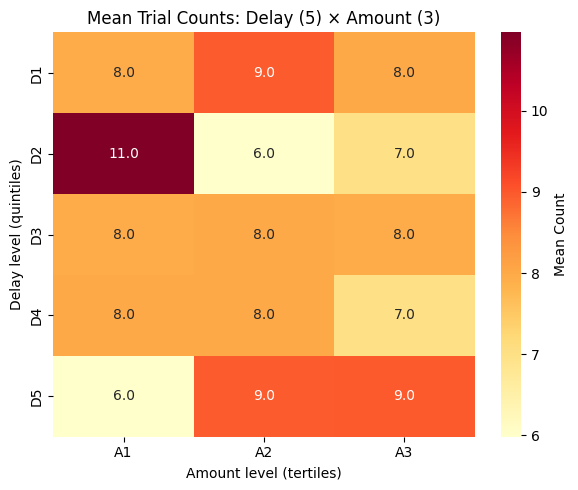

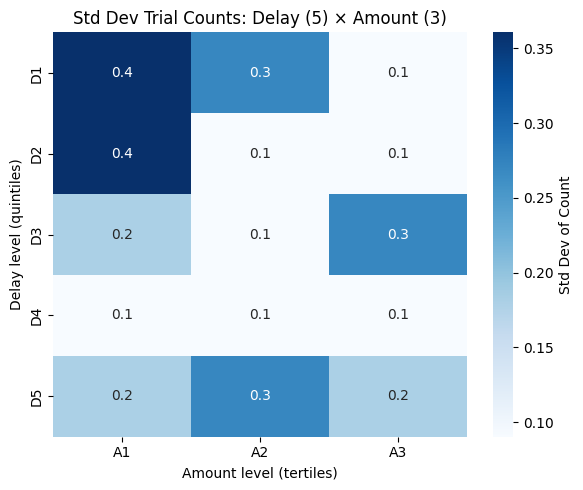

In [8]:
# 5 levels of delay (quintiles) and 3 levels of amount (tertiles)
import seaborn as sns

mvpa_merged_df['delay_5lvl'] = pd.qcut(
    mvpa_merged_df['Delay'],
    q=5,
    labels=[f'D{i + 1}' for i in range(5)],
    duplicates='drop',
)

mvpa_merged_df['amount_3lvl'] = pd.qcut(
    mvpa_merged_df['amount'],
    q=3,
    labels=[f'A{i + 1}' for i in range(3)],
    duplicates='drop',
)

# Counts per subject for each delay x amount bin
bin_counts_5x3 = (
    mvpa_merged_df.groupby(['sub_id', 'delay_5lvl', 'amount_3lvl'])
    .size()
    .reset_index(name='count')
)

print(f'bin_counts_5x3 shape: {bin_counts_5x3.shape}')
print(bin_counts_5x3.head(12))

# Mean and std matrices across subjects
mean_counts_5x3 = bin_counts_5x3.pivot_table(
    index='delay_5lvl', columns='amount_3lvl', values='count', aggfunc='mean'
)
std_counts_5x3 = bin_counts_5x3.pivot_table(
    index='delay_5lvl', columns='amount_3lvl', values='count', aggfunc='std'
)

display(mean_counts_5x3)
display(std_counts_5x3)

# Figure 1: mean counts heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    mean_counts_5x3,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Mean Count'},
)
plt.title('Mean Trial Counts: Delay (5) × Amount (3)')
plt.xlabel('Amount level (tertiles)')
plt.ylabel('Delay level (quintiles)')
plt.tight_layout()
plt.show()

# Figure 2: std counts heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    std_counts_5x3,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Std Dev of Count'},
)
plt.title('Std Dev Trial Counts: Delay (5) × Amount (3)')
plt.xlabel('Amount level (tertiles)')
plt.ylabel('Delay level (quintiles)')
plt.tight_layout()
plt.show()


Configured bins: delay=3, amount=3
bin_counts_cfg shape: (1107, 4)
     sub_id log_delay_lvl amount_lvl  count
0   dmp0011            D1         A1     16
1   dmp0011            D1         A2     15
2   dmp0011            D1         A3     14
3   dmp0011            D2         A1     13
4   dmp0011            D2         A2     11
5   dmp0011            D2         A3     11
6   dmp0011            D3         A1     12
7   dmp0011            D3         A2     14
8   dmp0011            D3         A3     14
9   dmp0019            D1         A1     16
10  dmp0019            D1         A2     15
11  dmp0019            D1         A3     14


/tmp/ipykernel_12730/4085318465.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvpa_merged_df.groupby(['sub_id', 'log_delay_lvl', 'amount_lvl'])
/tmp/ipykernel_12730/4085318465.py:51: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_counts_cfg = bin_counts_cfg.pivot_table(
/tmp/ipykernel_12730/4085318465.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std_counts_cfg = bin_counts_cfg.pivot_table(


amount_lvl,A1,A2,A3
log_delay_lvl,,,
D1,15.943089,14.96748,13.98374
D2,12.975610,10.99187,10.97561
D3,11.975610,13.96748,13.97561


amount_lvl,A1,A2,A3
log_delay_lvl,,,
D1,0.631169,0.360668,0.180334
D2,0.270501,0.090167,0.270501
D3,0.270501,0.360668,0.270501


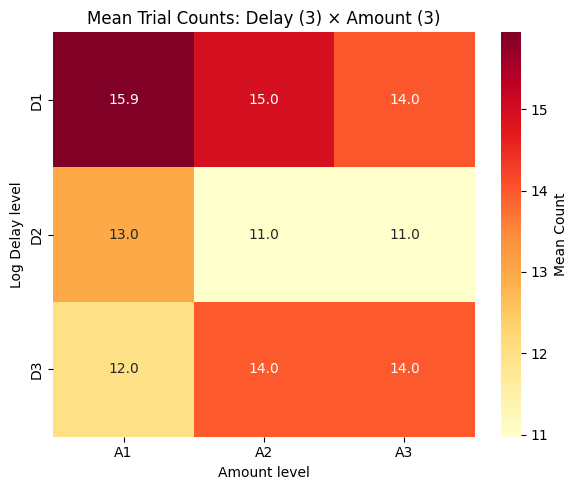

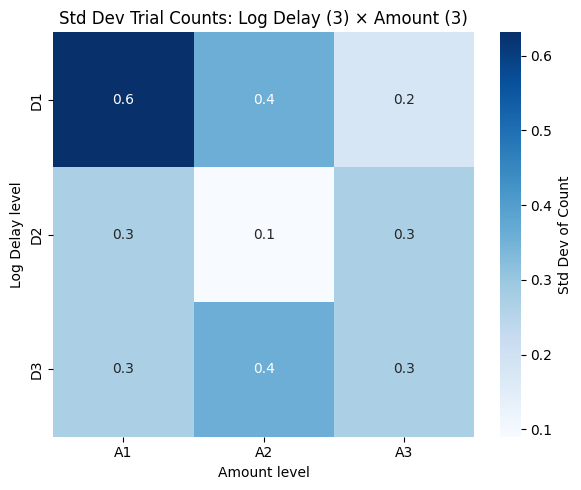

In [ ]:
import numpy as np
import seaborn as sns

# CHANGING TO LOG DELAY

# ======== CONFIG: change bins here ========
n_delay_levels = 3
n_amount_levels = 3
delay_prefix = 'D'
amount_prefix = 'A'
# ==========================================

# Build labels from config so they always match q
_delay_labels = [f'{delay_prefix}{i + 1}' for i in range(n_delay_levels)]
_amount_labels = [f'{amount_prefix}{i + 1}' for i in range(n_amount_levels)]

# mvpa_merged_df['delay_lvl'] = pd.qcut(
#     mvpa_merged_df['Delay'],
#     q=n_delay_levels,
#     labels=_delay_labels,
#     duplicates='drop',
# )

mvpa_merged_df['log_delay_lvl'] = pd.qcut(
    np.log1p(mvpa_merged_df['Delay'].astype(float)),
    q=n_delay_levels,
    labels=_delay_labels,
    duplicates='drop',
)


mvpa_merged_df['amount_lvl'] = pd.qcut(
    mvpa_merged_df['amount'],
    q=n_amount_levels,
    labels=_amount_labels,
    duplicates='drop',
)

# Counts per subject for each delay x amount bin
bin_counts_cfg = (
    mvpa_merged_df.groupby(['sub_id', 'log_delay_lvl', 'amount_lvl'])
    .size()
    .reset_index(name='count')
)

print(f'Configured bins: delay={n_delay_levels}, amount={n_amount_levels}')
print(f'bin_counts_cfg shape: {bin_counts_cfg.shape}')
print(bin_counts_cfg.head(12))

# Mean and std matrices across subjects
mean_counts_cfg = bin_counts_cfg.pivot_table(
    index='log_delay_lvl', columns='amount_lvl', values='count', aggfunc='mean'
)
std_counts_cfg = bin_counts_cfg.pivot_table(
    index='log_delay_lvl', columns='amount_lvl', values='count', aggfunc='std'
)

display(mean_counts_cfg)
display(std_counts_cfg)

# Figure 1: mean counts heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    mean_counts_cfg,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Mean Count'},
)
plt.title(f'Mean Trial Counts: Delay ({n_delay_levels}) × Amount ({n_amount_levels})')
plt.xlabel('Amount level')
plt.ylabel('Log Delay level')
plt.tight_layout()
plt.show()

# Figure 2: std counts heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    std_counts_cfg,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Std Dev of Count'},
)
plt.title(
    f'Std Dev Trial Counts: Log Delay ({n_delay_levels}) × Amount ({n_amount_levels})'
)
plt.xlabel('Amount level')
plt.ylabel('Log Delay level')
plt.tight_layout()
plt.show()


In [10]:
from concurrent.futures import ProcessPoolExecutor
from typing import Iterable

import nibabel as nib
import numpy as np
import pandas as pd

from dd_kable_analysis.config_loader import load_config
from dd_kable_analysis.data_io import load_tsv_data, resolve_file
from dd_kable_analysis.mvpa import build_subject_behav_bold_df
from dd_kable_analysis.mvpa.atlas import get_roi_labels_from_atlas_img, resolve_atlas

# ROI sets supported by dd_kable_analysis.mvpa.atlas.resolve_atlas(...)
AVAILABLE_ROI_SETS = [
    'josh_orig',
    'schaefer200',
    'schaefer400',
    'harvard_oxford_subcort',
    'pauli_rois',
]


# ── Parallel file loading ────────────────────────────────────────────────────


def _load_single_beta(args):
    """Load one .nii.gz beta map and extract ROI voxels via boolean mask.

    Designed to be called via ProcessPoolExecutor so gzip decompression
    runs on a separate core.
    """
    fpath, mask_bool = args
    vol = nib.load(fpath).get_fdata()
    return vol[mask_bool].astype(np.float32)


# ── CV plan ──────────────────────────────────────────────────────────────────


def make_loso_nested_cv(subject_ids: Iterable[str]):
    """Build outer LOSO folds + inner LOSO folds on the outer-train subjects."""
    subjects = [str(s) for s in subject_ids]
    folds = []
    for test_sub in subjects:
        train_subs = [s for s in subjects if s != test_sub]
        inner = []
        for inner_val_sub in train_subs:
            inner_train = [s for s in train_subs if s != inner_val_sub]
            inner.append({'train_subjects': inner_train, 'val_subject': inner_val_sub})
        folds.append(
            {
                'outer_test_subject': test_sub,
                'outer_train_subjects': train_subs,
                'inner_folds': inner,
            }
        )
    return folds


# ── Behavioral data ──────────────────────────────────────────────────────────


def load_all_behavior_and_delay_bins(
    cfg=None,
    *,
    subject_list_name: str = 'mvpa_subject_list.txt',
    n_delay_bins: int = 5,
    ses: str = 'scan1',
    run_ids: Iterable[int] = range(1, 6),
    include_nested_loso_cv: bool = True,
):
    """
    Load all BIDS behavioral rows, derive global delay bins, and optionally build
    nested LOSO CV definitions.

    Returns
    -------
    all_behav_df, delay_bin_edges, delay_cutoffs_df, cv_plan
    """
    cfg = load_config() if cfg is None else cfg

    subject_list_path = cfg.subject_lists / subject_list_name
    subject_ids = [
        line.strip()
        for line in subject_list_path.read_text().splitlines()
        if line.strip()
    ]

    rows = []
    missing = []

    for sub_id in subject_ids:
        found_any = False
        for run in run_ids:
            run_str = str(run)
            try:
                behav_file = resolve_file(cfg, sub_id, ses, run_str, 'behav')
            except ValueError:
                continue

            found_any = True
            df = load_tsv_data(behav_file).copy()
            df['sub_id'] = sub_id
            df['run'] = run_str
            df['source_bids_tsv'] = str(behav_file)
            rows.append(df)

        if not found_any:
            missing.append(sub_id)

    if not rows:
        raise ValueError('No behavioral files were found for any subject/run.')

    all_behav_df = pd.concat(rows, ignore_index=True)
    all_behav_df['Delay'] = pd.to_numeric(all_behav_df['Delay'], errors='coerce')

    valid_delay = all_behav_df['Delay'].dropna()
    if valid_delay.empty:
        raise ValueError('Delay column is empty after numeric coercion.')

    _, delay_bin_edges = pd.qcut(
        valid_delay,
        q=n_delay_bins,
        retbins=True,
        duplicates='drop',
    )

    delay_bin_cat = pd.cut(
        all_behav_df['Delay'],
        bins=np.asarray(delay_bin_edges, dtype=float),
        include_lowest=True,
    )
    all_behav_df['delay_bin'] = delay_bin_cat

    delay_codes = delay_bin_cat.cat.codes.to_numpy()  # -1 for NaN / out-of-range
    all_behav_df['delay_bin_index'] = pd.Series(
        np.where(delay_codes >= 0, delay_codes + 1, np.nan),
        index=all_behav_df.index,
    ).astype('Int64')

    delay_cutoffs_df = pd.DataFrame(
        {
            'delay_bin_index': np.arange(1, len(delay_bin_edges)),
            'lower': delay_bin_edges[:-1],
            'upper': delay_bin_edges[1:],
        }
    )

    cv_plan = make_loso_nested_cv(subject_ids) if include_nested_loso_cv else None

    if missing:
        print(f'Subjects with no behavior files found: {len(missing)}')

    print(
        f'Loaded behavior rows={len(all_behav_df)} | subjects={all_behav_df.sub_id.nunique()} | '
        f'delay_bins_requested={n_delay_bins} | delay_bins_actual={len(delay_bin_edges) - 1}'
    )

    return all_behav_df, delay_bin_edges, delay_cutoffs_df, cv_plan


# ── Atlas / ROI helpers ──────────────────────────────────────────────────────


def get_roi_labels_for_set(cfg, roi_set: str, atlas_path: str | None = None):
    """Return sorted ROI labels for an atlas/ROI set."""
    if atlas_path is None and roi_set not in AVAILABLE_ROI_SETS:
        raise ValueError(
            f'Unknown roi_set={roi_set!r}. Use one of {AVAILABLE_ROI_SETS} '
            'or pass atlas_path for a custom atlas.'
        )
    atlas_img, atlas_source = resolve_atlas(cfg, roi_set, atlas_path)
    labels = sorted(get_roi_labels_from_atlas_img(atlas_img))
    return atlas_img, atlas_source, labels


def make_single_roi_mask(atlas_img, roi_label: int):
    """Create a binary mask image for one ROI label from a label atlas."""
    img = nib.load(str(atlas_img)) if not hasattr(atlas_img, 'get_fdata') else atlas_img
    data = img.get_fdata()
    roi_mask = (np.round(data).astype(int) == int(roi_label)).astype(np.uint8)
    return nib.Nifti1Image(roi_mask, img.affine, img.header)


from nilearn.image import resample_to_img


def make_roi_bool_mask(atlas_img, roi_label: int, reference_img=None) -> np.ndarray:
    """Create a boolean 3-D mask array for one ROI label,
    optionally resampled to match a reference image grid."""
    img = nib.load(str(atlas_img)) if not hasattr(atlas_img, 'get_fdata') else atlas_img
    data = img.get_fdata()
    roi_mask = (np.round(data).astype(int) == int(roi_label)).astype(np.uint8)
    mask_img = nib.Nifti1Image(roi_mask, img.affine, img.header)

    if reference_img is not None:
        mask_img = resample_to_img(
            mask_img,
            reference_img,
            interpolation='nearest',  # critical — keeps mask binary
            copy_header=True,  # Add this line to suppress FutureWarning
        )

    return mask_img.get_fdata().astype(bool)


# ── Within-subject z-scoring ─────────────────────────────────────────────────


def zscore_within_voxel(X: np.ndarray) -> np.ndarray:
    """Z-score columns (voxels) within subject across trials."""
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0)
    sd_safe = np.where(sd == 0, 1.0, sd)
    Z = (X - mu) / sd_safe
    Z[:, sd == 0] = 0.0
    return Z


# ── Per-subject trial table ─────────────────────────────────────────────────


def build_subject_trial_table_with_bins(
    cfg,
    sub_id: str,
    behav_with_bins_df: pd.DataFrame,
    *,
    beta_series_subdir: str = 'beta_series',
    min_runs_required: int = 3,
    min_trials_per_run: int = 20,
    strict: bool = True,
    verbose: bool = False,
):
    """Build subject trial table with beta file paths and delay bin info."""
    subj = build_subject_behav_bold_df(
        cfg,
        sub_id=sub_id,
        y_col='amount',
        beta_series_subdir=beta_series_subdir,
        min_runs_required=min_runs_required,
        min_trials_per_run=min_trials_per_run,
        strict=strict,
        verbose=verbose,
    )
    df = subj.behav_bold_df.copy()
    if df.empty:
        return df

    df['sub_id'] = str(sub_id)
    df['run'] = df['run'].astype(str)

    b = behav_with_bins_df.copy()
    b['sub_id'] = b['sub_id'].astype(str)
    b['run'] = b['run'].astype(str)
    b = b.loc[b['sub_id'] == str(sub_id)].copy()

    merge_cols = ['sub_id', 'run', 'trial_type']
    if ('trial_type' in b.columns) and ('trial_type' in df.columns):
        keep_cols = merge_cols + [
            c for c in ['delay_bin', 'delay_bin_index'] if c in b.columns
        ]
        b1 = b[keep_cols].drop_duplicates(subset=merge_cols, keep='first')
        out = df.merge(b1, on=merge_cols, how='left', validate='many_to_one')
        if out['delay_bin_index'].notna().any():
            return out

    if ('onset' in b.columns) and ('onset' in df.columns):
        b2 = b.copy()
        b2['_onset_key'] = pd.to_numeric(b2['onset'], errors='coerce').round(6)
        d2 = df.copy()
        d2['_onset_key'] = pd.to_numeric(d2['onset'], errors='coerce').round(6)
        keep_cols = ['sub_id', 'run', '_onset_key'] + [
            c for c in ['delay_bin', 'delay_bin_index'] if c in b2.columns
        ]
        b2 = b2[keep_cols].drop_duplicates(
            subset=['sub_id', 'run', '_onset_key'], keep='first'
        )
        out = d2.merge(
            b2,
            on=['sub_id', 'run', '_onset_key'],
            how='left',
            validate='many_to_one',
        ).drop(columns=['_onset_key'])
        return out

    return df


# ── Per-subject voxel extraction (parallel) ──────────────────────────────────
def extract_subject_roi_trial_voxels(
    subject_trial_df: pd.DataFrame,
    mask_bool: np.ndarray,  # Accept pre-made mask, not atlas_img
    *,
    zscore_voxels_within_subject: bool = True,
    n_workers: int = 8,
):
    """Extract trial×voxel matrix for one subject using parallel file reads.

    Parameters
    ----------
    subject_trial_df : DataFrame
        Must contain a 'beta_file' column with paths to single-trial .nii.gz files.
    mask_bool : np.ndarray
        3-D boolean array marking ROI voxels (already in correct space).
    zscore_voxels_within_subject : bool
        Z-score each voxel across trials within this subject.
    n_workers : int
        Number of parallel processes for gzip decompression.
    """
    if subject_trial_df.empty:
        return np.empty((0, 0)), subject_trial_df.copy()

    # Stable ordering for traceability
    df = subject_trial_df.copy()
    if 'trial_type' in df.columns:
        trial_num = (
            df['trial_type'].astype(str).str.extract(r'trial(\d+)')[0].astype(float)
        )
        df['_trial_num'] = trial_num
    else:
        df['_trial_num'] = np.nan
    sort_cols = [c for c in ['run', '_trial_num', 'onset'] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols).reset_index(drop=True)

    beta_files = df['beta_file'].astype(str).tolist()

    # Use pre-made mask directly (no mask creation here)
    args = [(f, mask_bool) for f in beta_files]
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        rows = list(pool.map(_load_single_beta, args))
    X = np.vstack(rows)

    if zscore_voxels_within_subject and X.size:
        X = zscore_within_voxel(X)

    df = df.drop(columns=['_trial_num'])
    return X, df


# ── Main collection function ─────────────────────────────────────────────────


def collect_roi_trial_voxel_data_all_subjects(
    *,
    roi_set: str,
    roi_index: int,
    behav_with_bins_df: pd.DataFrame,
    cfg=None,
    atlas_path: str | None = None,
    subject_list_name: str = 'mvpa_subject_list.txt',
    beta_series_subdir: str = 'beta_series',
    min_runs_required: int = 3,
    min_trials_per_run: int = 20,
    strict: bool = True,
    zscore_voxels_within_subject: bool = True,
    n_workers: int = 8,
    verbose: bool = True,
):
    """
    For one ROI index, extract trial×voxel data for all subjects using parallel
    file reads, z-score within subject/voxel, concatenate, then drop any voxel
    that is all-zero for at least one subject.

    Returns
    -------
    X_all : np.ndarray
        Concatenated matrix (all trials across subjects × kept voxels).
    trial_info_df : pd.DataFrame
        Row-aligned trial metadata, includes subject/run/trial + delay bins.
    voxel_info_df : pd.DataFrame
        Column metadata for kept voxels in this ROI.
    """
    cfg = load_config() if cfg is None else cfg

    subject_list_path = cfg.subject_lists / subject_list_name
    subject_ids = [
        line.strip()
        for line in subject_list_path.read_text().splitlines()
        if line.strip()
    ]

    atlas_img, atlas_source, roi_labels = get_roi_labels_for_set(
        cfg, roi_set, atlas_path
    )

    if roi_index < 0 or roi_index >= len(roi_labels):
        raise IndexError(
            f'roi_index={roi_index} out of range for {roi_set}; valid 0..{len(roi_labels) - 1}'
        )
    roi_label = roi_labels[roi_index]

    # Find first valid beta file to use as reference for mask creation
    reference_beta_img = None
    for sub_id in subject_ids:
        try:
            subj_df = build_subject_trial_table_with_bins(
                cfg,
                sub_id,
                behav_with_bins_df,
                beta_series_subdir=beta_series_subdir,
                min_runs_required=min_runs_required,
                min_trials_per_run=min_trials_per_run,
                strict=strict,
                verbose=False,
            )
            if not subj_df.empty and 'beta_file' in subj_df.columns:
                first_beta = subj_df['beta_file'].iloc[0]
                reference_beta_img = nib.load(str(first_beta))
                break
        except Exception:
            continue

    if reference_beta_img is None:
        raise ValueError(
            'Could not find any valid beta file to use as reference for mask creation'
        )

    # Create mask once using reference beta
    mask_bool = make_roi_bool_mask(
        atlas_img, roi_label, reference_img=reference_beta_img
    )
    n_vox_mask = int(mask_bool.sum())

    if verbose:
        print(
            f'ROI set={roi_set} | roi_index={roi_index} | roi_label={roi_label} | '
            f'mask voxels={n_vox_mask} | loading {len(subject_ids)} subjects '
            f'with {n_workers} workers ...'
        )

    X_by_sub = []
    info_by_sub = []

    for sub_id in subject_ids:
        try:
            subj_df = build_subject_trial_table_with_bins(
                cfg,
                sub_id,
                behav_with_bins_df,
                beta_series_subdir=beta_series_subdir,
                min_runs_required=min_runs_required,
                min_trials_per_run=min_trials_per_run,
                strict=strict,
                verbose=False,
            )
        except Exception as exc:
            if verbose:
                print(f'[skip] sub-{sub_id}: {exc}')
            continue

        if subj_df.empty:
            continue

        X_sub, info_sub = extract_subject_roi_trial_voxels(
            subj_df,
            mask_bool,  # Pass pre-made mask
            zscore_voxels_within_subject=zscore_voxels_within_subject,
            n_workers=n_workers,
        )

        if X_sub.shape[0] == 0:
            continue

        info_sub = info_sub.copy().reset_index(drop=True)
        info_sub['sub_id'] = str(sub_id)
        info_sub['roi_set'] = str(roi_set)
        info_sub['roi_label'] = int(roi_label)
        info_sub['roi_index'] = int(roi_index)
        info_sub['atlas_source'] = str(atlas_source)

        X_by_sub.append(X_sub)
        info_by_sub.append(info_sub)

    if not X_by_sub:
        raise ValueError('No subject data extracted for this ROI.')

    n_vox = X_by_sub[0].shape[1]
    if any(x.shape[1] != n_vox for x in X_by_sub):
        raise ValueError(
            'Voxel count mismatch across subjects for this ROI extraction.'
        )

    # Drop voxels that are all zeros in ANY subject
    zero_by_sub = np.vstack([np.all(np.isclose(x, 0.0), axis=0) for x in X_by_sub])
    drop_vox = np.any(zero_by_sub, axis=0)
    keep_vox = ~drop_vox

    X_by_sub = [x[:, keep_vox] for x in X_by_sub]
    X_all = np.vstack(X_by_sub)
    trial_info_df = pd.concat(info_by_sub, ignore_index=True)

    voxel_info_df = pd.DataFrame(
        {
            'roi_set': str(roi_set),
            'roi_label': int(roi_label),
            'roi_index': int(roi_index),
            'voxel_index_within_roi_original': np.arange(n_vox, dtype=int),
            'kept_after_subject_zero_filter': keep_vox,
        }
    )
    voxel_info_df = voxel_info_df.loc[
        voxel_info_df['kept_after_subject_zero_filter']
    ].copy()
    voxel_info_df['voxel_index_within_roi_kept'] = np.arange(
        len(voxel_info_df), dtype=int
    )

    n_kept = int(keep_vox.sum())
    if verbose:
        print(
            f'ROI set={roi_set} | roi_index={roi_index} | roi_label={roi_label} | '
            f'subjects_kept={len(X_by_sub)} | X_all shape={X_all.shape} | '
            f'vox_dropped={int(drop_vox.sum())} | vox_kept={n_kept}'
        )

    return X_all, trial_info_df, voxel_info_df

In [11]:
# Run Step 0 with 3 delay bins (+ nested LOSO CV plan)
all_behav_df_3bins, delay_bin_edges_3, delay_cutoffs_df_3, nested_loso_cv_3bins = (
    load_all_behavior_and_delay_bins(
        cfg=cfg,
        n_delay_bins=3,
        include_nested_loso_cv=True,
    )
)

print('Delay bin edges (3 bins):', delay_bin_edges_3)
print('Outer folds in nested LOSO:', len(nested_loso_cv_3bins))
display(delay_cutoffs_df_3)
all_behav_df_3bins.head()

Loaded behavior rows=14730 | subjects=123 | delay_bins_requested=3 | delay_bins_actual=3
Delay bin edges (3 bins): [ 19.          74.         128.33333333 180.        ]
Outer folds in nested LOSO: 123


/tmp/ipykernel_11277/2086581691.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_behav_df = pd.concat(rows, ignore_index=True)


,delay_bin_index,lower,upper
0,1,19.000000,74.000000
1,2,74.000000,128.333333
2,3,128.333333,180.000000


,onset,duration,amount,Delay,choseAccept,RT,choseRight,sub_id,run,source_bids_tsv,delay_bin,delay_bin_index
0,15.822,4,66,58,1.0,1.993,1.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,"(18.999, 74.0]",1
1,24.855,4,39,95,0.0,1.024,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,"(74.0, 128.333]",2
2,32.888,4,69,172,0.0,1.071,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,"(128.333, 180.0]",3
3,42.937,4,23,42,0.0,1.101,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,"(18.999, 74.0]",1
4,56.987,4,77,142,1.0,1.739,1.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,"(128.333, 180.0]",3


In [12]:
# Run ROI extraction for first ROI in josh_orig across all MVPA subjects
X_roi_all, trial_info_roi_all, voxel_info_roi_all = (
    collect_roi_trial_voxel_data_all_subjects(
        roi_set='josh_orig',
        roi_index=0,
        behav_with_bins_df=all_behav_df_3bins,
        cfg=cfg,
        zscore_voxels_within_subject=True,
        verbose=True,
    )
)

print('X shape:', X_roi_all.shape)
print('Trial info shape:', trial_info_roi_all.shape)
print('Voxel info shape:', voxel_info_roi_all.shape)

display(trial_info_roi_all[['sub_id', 'run', 'trial_type', 'delay_bin_index']].head())
display(voxel_info_roi_all.head())

/tmp/ipykernel_11277/2086581691.py:197: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_img = resample_to_img(


ROI set=josh_orig | roi_index=0 | roi_label=1 | mask voxels=805 | loading 123 subjects with 8 workers ...
[skip] sub-dmp0063: ❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.
[skip] sub-dmp0148: [dmp0148] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp0492: [dmp0492] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp0521: [dmp0521] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp0587: [dmp0587] has only 1 QA-passed runs; requires >= 3.
[skip] sub-dmp0678: [dmp0678] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp0844: [dmp0844] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp1000: [dmp1000] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp1037: [dmp1037] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp1064: [dmp1064] has only 2 QA-passed runs; requires >= 3.
[skip] sub-dmp1135: [dmp1135] has only 1 QA-passed runs; requires >= 3.
[skip] sub-dmp1231: [dmp1231] has only 2 QA-passed runs; requires >= 3.
ROI

,sub_id,run,trial_type,delay_bin_index
0,dmp0011,1,trial00,1
1,dmp0011,1,trial01,2
2,dmp0011,1,trial02,3
3,dmp0011,1,trial03,1
4,dmp0011,1,trial04,3


,roi_set,roi_label,roi_index,voxel_index_within_roi_original,kept_after_subject_zero_filter,voxel_index_within_roi_kept
0,josh_orig,1,0,0,True,0
1,josh_orig,1,0,1,True,1
2,josh_orig,1,0,2,True,2
3,josh_orig,1,0,3,True,3
4,josh_orig,1,0,4,True,4


In [30]:
from functools import partial
from typing import Any

import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneGroupOut


def _fit_single_fold(fold_data, alphas, inner_cv_strategy, inner_cv_folds):
    """Fit one outer fold - designed for parallel execution."""
    train_idx, test_idx, X, y, subjects = fold_data

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    subjects_train = subjects[train_idx]

    # Inner CV for alpha selection
    if inner_cv_strategy == 'loso':
        logo_inner = LeaveOneGroupOut()
        ridge = RidgeCV(
            alphas=alphas,
            cv=logo_inner.split(X_train, y_train, groups=subjects_train),
            scoring='r2',
        )
    else:  # kfold
        print('DEBUG: running kfold CV for inner alpha selection', flush=True)
        ridge = RidgeCV(
            alphas=alphas,
            cv=KFold(n_splits=inner_cv_folds, shuffle=True, random_state=42),
            scoring='r2',
        )
    print('DEBUGGING: kfold finished')
    ridge.fit(X_train, y_train)
    print('DEBUG: ridge.fit() completed', flush=True)
    yhat_fold = ridge.predict(X_test)
    print('DEBUG: ridge.predict() completed', flush=True)
    return test_idx, yhat_fold, ridge.alpha_


def nested_loso_ridge_predict(
    X: np.ndarray,
    y: np.ndarray,
    subjects: np.ndarray,
    *,
    alphas: np.ndarray | None = None,
    inner_cv_strategy: str = 'kfold',
    inner_cv_folds: int = 5,
    n_jobs: int = 1,
    verbose: bool = False,
) -> tuple[np.ndarray, dict[str, Any]]:
    """
    Nested leave-one-subject-out ridge regression with inner CV for alpha selection.

    Outer loop: LOSO across subjects
    Inner loop: k-fold CV (or LOSO) across remaining subjects to select alpha

    Parameters
    ----------
    X : np.ndarray
        Trial × voxel feature matrix (already concatenated across subjects).
    y : np.ndarray
        Target variable (e.g., 'amount') for all trials.
    subjects : np.ndarray
        Subject ID for each trial (same length as y).
    alphas : np.ndarray | None
        Ridge alpha grid. If None, uses [0.01, 0.1, 1, 10, 100, 1000, 10000].
    inner_cv_strategy : str
        'loso' for leave-one-subject-out inner CV, or 'kfold' for k-fold.
    inner_cv_folds : int
        Number of folds if inner_cv_strategy='kfold'.
    n_jobs : int
        Number of parallel workers for outer folds. 1 = sequential, -1 = use all cores.
    verbose : bool
        Print progress for each outer fold.

    Returns
    -------
    yhat : np.ndarray
        Out-of-sample predictions for all trials (same order as y).
    info : dict
        Contains: r, r2_cv, rmse, chosen_alphas (one per outer fold).
    """
    if alphas is None:
        alphas = np.array([0.01, 0.1, 1, 10, 100, 1000, 10000])

    unique_subjects = np.unique(subjects)
    n_subjects = len(unique_subjects)

    if verbose:
        print('\nStarting nested LOSO ridge regression:')
        print(f'  - Outer CV: {n_subjects} subjects (LOSO)')
        print(f'  - Inner CV: {inner_cv_strategy}', end='')
        if inner_cv_strategy == 'kfold':
            print(f' ({inner_cv_folds} folds)')
        else:
            print(f' (~{n_subjects - 1} folds per outer fold)')
        print(f'  - Alpha grid: {len(alphas)} values')
        print(f'  - Parallelization: {n_jobs} workers')
        print(f'  - Total trials: {len(y)}')
        print(f'  - Total voxels: {X.shape[1]}')
        print()

    yhat = np.full_like(y, np.nan, dtype=float)

    logo_outer = LeaveOneGroupOut()

    # Prepare all fold data
    fold_data_list = []
    for train_idx, test_idx in logo_outer.split(X, y, groups=subjects):
        fold_data_list.append((train_idx, test_idx, X, y, subjects))
    print(f'DEBUG: Created {len(fold_data_list)} folds', flush=True)  # ADD THIS

    if n_jobs == 1:
        print('DEBUG: Entering sequential execution', flush=True)  # ADD THIS
        # Sequential execution
        chosen_alphas = []
        for fold_idx, fold_data in enumerate(fold_data_list):
            print(f'DEBUG: Starting fold {fold_idx}', flush=True)  # ADD THIS
            test_idx, yhat_fold, alpha = _fit_single_fold(
                fold_data, alphas, inner_cv_strategy, inner_cv_folds
            )
            yhat[test_idx] = yhat_fold
            chosen_alphas.append(alpha)

            if verbose:
                test_subject = subjects[test_idx[0]]
                print(
                    f'  [{fold_idx + 1:3d}/{n_subjects}] '
                    f'test_subject={test_subject} | alpha={alpha:8.2f} | '
                    f'n_train={len(fold_data[0]):5d} | n_test={len(test_idx):3d}'
                )
    else:
        # Parallel execution with real-time progress updates
        if verbose:
            print(f'Running {n_subjects} folds in parallel with {n_jobs} workers...\n')

        fit_func = partial(
            _fit_single_fold,
            alphas=alphas,
            inner_cv_strategy=inner_cv_strategy,
            inner_cv_folds=inner_cv_folds,
        )

        import time
        from concurrent.futures import as_completed

        test_subject = subjects[test_idx[0]]
        print(f'Starting fold for subject {test_subject}', flush=True)

        start_time = time.time()

        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            # Submit all jobs and track them
            future_to_fold = {
                executor.submit(fit_func, fold_data): (
                    fold_idx,
                    subjects[fold_data[1][0]],
                )
                for fold_idx, fold_data in enumerate(fold_data_list)
            }

            # Collect results as they complete
            results = [None] * n_subjects
            chosen_alphas = [None] * n_subjects

            for completed_count, future in enumerate(as_completed(future_to_fold), 1):
                fold_idx, test_subject = future_to_fold[future]
                test_idx, yhat_fold, alpha = future.result()

                yhat[test_idx] = yhat_fold
                results[fold_idx] = (test_idx, yhat_fold, alpha)
                chosen_alphas[fold_idx] = alpha

                if verbose:
                    elapsed = time.time() - start_time
                    rate = completed_count / elapsed
                    remaining = (n_subjects - completed_count) / rate if rate > 0 else 0

                    print(
                        f'  [{completed_count:3d}/{n_subjects}] '
                        f'fold {fold_idx + 1:3d} | subject={test_subject} | alpha={alpha:8.2f} | '
                        f'elapsed={elapsed / 60:.1f}m | remaining~{remaining / 60:.1f}m'
                    )

        if verbose:
            total_time = time.time() - start_time
            print(
                f'\nAll {n_subjects} folds completed in {total_time / 60:.1f} minutes'
            )
    # Compute metrics on all out-of-sample predictions
    valid_mask = ~np.isnan(yhat)
    y_valid = y[valid_mask]
    yhat_valid = yhat[valid_mask]

    r = float(np.corrcoef(y_valid, yhat_valid)[0, 1]) if len(y_valid) > 1 else np.nan
    r2_cv = float(r2_score(y_valid, yhat_valid))
    rmse = float(np.sqrt(mean_squared_error(y_valid, yhat_valid)))

    if verbose:
        print('\nOut-of-sample performance:')
        print(f'  - Pearson r: {r:.4f}')
        print(f'  - R² (CV):   {r2_cv:.4f}')
        print(f'  - RMSE:      {rmse:.4f}')
        print(f'  - Mean alpha: {np.mean(chosen_alphas):.2f}')
        print()

    info = {
        'r': r,
        'r2_cv': r2_cv,
        'rmse': rmse,
        'chosen_alphas': chosen_alphas,
        'n_folds': n_subjects,
    }

    return yhat, info


def decode_across_subjects_single_roi(
    X_all: np.ndarray,
    trial_info_df: pd.DataFrame,
    voxel_info_df: pd.DataFrame,
    *,
    y_col: str = 'amount',
    subject_col: str = 'sub_id',
    alphas: np.ndarray | None = None,
    inner_cv_strategy: str = 'kfold',
    inner_cv_folds: int = 5,
    n_jobs: int = 1,  # NEW
    verbose: bool = False,
    return_trialwise: bool = False,
) -> dict[str, Any] | tuple[dict[str, Any], pd.DataFrame]:
    if y_col not in trial_info_df.columns:
        raise ValueError(f"y_col='{y_col}' not found in trial_info_df")
    if subject_col not in trial_info_df.columns:
        raise ValueError(f"subject_col='{subject_col}' not found in trial_info_df")

    y = trial_info_df[y_col].values
    subjects = trial_info_df[subject_col].values

    # Check for missing values
    valid_mask = ~np.isnan(y)
    if not valid_mask.all():
        if verbose:
            print(
                f'Warning: {(~valid_mask).sum()} trials have missing y values, dropping them'
            )
        X_all = X_all[valid_mask]
        trial_info_df = trial_info_df.loc[valid_mask].reset_index(drop=True)
        y = y[valid_mask]
        subjects = subjects[valid_mask]

    # Run nested LOSO ridge
    yhat, info = nested_loso_ridge_predict(
        X_all,
        y,
        subjects,
        alphas=alphas,
        inner_cv_strategy=inner_cv_strategy,
        inner_cv_folds=inner_cv_folds,
        n_jobs=n_jobs,  # NEW
        verbose=verbose,
    )

    # Extract ROI metadata
    roi_label = int(voxel_info_df['roi_label'].iloc[0])
    roi_set = str(voxel_info_df['roi_set'].iloc[0])
    n_voxels = int(len(voxel_info_df))

    r = info['r']
    summary = {
        'roi_set': roi_set,
        'roi_label': roi_label,
        'n_trials': int(len(y)),
        'n_subjects': int(len(np.unique(subjects))),
        'n_voxels': n_voxels,
        'r': r,
        'fisher_z': float(np.arctanh(np.clip(r, -0.999999, 0.999999))),
        'r2_cv': info['r2_cv'],
        'rmse': info['rmse'],
        'mean_alpha': float(np.mean(info['chosen_alphas'])),
    }

    if return_trialwise:
        trialwise_df = trial_info_df.copy()
        trialwise_df['y'] = y
        trialwise_df['yhat_oos'] = yhat
        trialwise_df['roi_set'] = roi_set
        trialwise_df['roi_label'] = roi_label
        return summary, trialwise_df

    return summary

In [32]:
summary = decode_across_subjects_single_roi(
    X_roi_all,
    trial_info_roi_all,
    voxel_info_roi_all,
    y_col='amount',
    n_jobs=1,
    alphas=np.array([100]),  # Just one alpha
    inner_cv_folds=2,
    verbose=True,
)

print(summary)


Starting nested LOSO ridge regression:
  - Outer CV: 111 subjects (LOSO)
  - Inner CV: kfold (2 folds)
  - Alpha grid: 1 values
  - Parallelization: 1 workers
  - Total trials: 11981
  - Total voxels: 804

DEBUG: Created 111 folds
DEBUG: Entering sequential execution
DEBUG: Starting fold 0


DEBUG: running kfold CV for inner alpha selection
DEBUGGING: kfold finished
DEBUG: ridge.fit() completed
DEBUG: ridge.predict() completed
  [  1/111] test_subject=dmp0011 | alpha=  100.00 | n_train=11865 | n_test=116
DEBUG: Starting fold 1
DEBUG: running kfold CV for inner alpha selection
DEBUGGING: kfold finished


KeyboardInterrupt: 

In [28]:
from sklearn.linear_model import LinearRegression, Ridge

# OLS version
print('Fitting OLS on all data...')
ols = LinearRegression()
ols.fit(X_roi_all, trial_info_roi_all['amount'].values)
yhat_ols = ols.predict(X_roi_all)

r_ols = np.corrcoef(trial_info_roi_all['amount'].values, yhat_ols)[0, 1]
print(f'OLS - In-sample r = {r_ols:.4f}')

# Ridge with fixed alpha for comparison
print('\nFitting Ridge (alpha=100) on all data...')
ridge_fixed = Ridge(alpha=100)
ridge_fixed.fit(X_roi_all, trial_info_roi_all['amount'].values)
yhat_ridge = ridge_fixed.predict(X_roi_all)

r_ridge = np.corrcoef(trial_info_roi_all['amount'].values, yhat_ridge)[0, 1]
print(f'Ridge (α=100) - In-sample r = {r_ridge:.4f}')

# Compare
print(f'\nDifference: {abs(r_ols - r_ridge):.4f}')

Fitting OLS on all data...
OLS - In-sample r = 0.2728

Fitting Ridge (alpha=100) on all data...
Ridge (α=100) - In-sample r = 0.2672

Difference: 0.0056
